# Running models in PorePy, part I: Geometry

## Models in PorePy
A model in porepy is defined by a combination of Python classes, where each class covers its own aspect of the model.
These aspects are:

* Geometry
* Equations
* Variables
* Constitutive laws
* Boundary conditions
* Solution strategy

and they are combined using multiple inheritance in Python.
Since the model classes are composed with relatively advanced use of Python inheritance and mixin, the reader is highly encouraged to familiarize themselves with those concepts.
We will not visit the technicalities about this, so we refer to [this blog post](https://www.thedigitalcatonline.com/blog/2020/03/27/mixin-classes-in-python/) for an introduction on the topic.

In PorePy all classes related to models except solution strategies are treated as Mixins. 
The solution strategy also defines an implicit contract between the functions used to run a simulation (run_time_dependent_problem) and the rest of the model.

Porepy provides complete models for several problems, and they are fully capable for running a simulation as they are. 
The user might be interested in modifying the model. The usual way of doing this is by overriding the pre-defined, default models. In this tutorial, we specifically focus on how to modify the geometry and meshing.

## Geometry

In this tutorial, we will show:

1. How to create the geometry for a simulation in PorePy, including defining the domain and creating the mesh.
2. How to define fractures and a fracture network in both 2D and 3D domains.
2. How to visualize the mesh.

This will be done using the aforementioned mixin framework for creating custom models in PorePy. Together, these are the first steps towards creating a simulation model for a mixed-dimensional problem in fractured domains.

The default geometry is a unitary domain without any fractures, and we will therefore look at how to modify it. 
Here we will demonstrate how this is done by overriding methods found within the ``set_geometry`` method found in ``pp.ModelGeometry``. 
This is where the geometry related methods and information are located.

More specifically, we will override the following methods:

* ``set_domain``
* ``set_fractures``
* ``grid_type``
* ``meshing_arguments`` 

In [1]:
import porepy as pp
import numpy as np
from porepy.applications.md_grids.domains import nd_cube_domain


class ModifiedGeometry:
    def set_domain(self) -> None:
        """Defining a two-dimensional square domain with sidelength 2."""
        size = self.units.convert_units(2, "m")
        self._domain = nd_cube_domain(2, size)

    def set_fractures(self) -> None:
        """Setting a diagonal fracture"""
        frac_1_points = self.units.convert_units(
            np.array([[0.2, 1.8], [1.0, 1.0]]), "m"
        )
        frac_1 = pp.LineFracture(frac_1_points)
        self._fractures = [frac_1]

    def grid_type(self) -> str:
        """Choosing the grid type for our domain.

        As we have a diagonal fracture we cannot use a cartesian grid.
        Cartesian grid is the default grid type, and we therefore override this method to assign simplex instead.

        """
        return self.params.get("grid_type", "simplex")

    def meshing_arguments(self) -> dict:
        """Meshing arguments for md-grid creation.

        Here we determine the cell size.

        """
        cell_size = self.units.convert_units(0.25, "m")
        mesh_args = {"cell_size": cell_size}
        return mesh_args
    
    def plot_fracture_geometry(self):
        network2d = pp.create_fracture_network(self._fractures, self._domain)
        network2d.plot()

We utilize the built-in PorePy method `nd_cube_domain` to define a two-dimensional square domain with sidelength 2. The fracture is defined in the method `set_fractures`. A two-dimensional fracture is defined by specifying the x- and y-coordinates of its endpoints. In this case, we define a fracture extending from (0.2,1.0) to (1.8,1.0). Then, we use the `grid_type` method to specify that we want a simplex grid. Finally, an overall target cell size is specified through the method `meshing_arguments`. Options for more advanced tuning of the mesh size are given in the tutorial on [mixed-dimensional meshing](./mixed_dimensional_meshing.ipynb).

We now combine our modified geometry class with a pre-defined single phase flow model in PorePy. This model can be found in the fluid_mass_balance.py file under the name SinglePhaseFlow.

Note that the modified geometry is listed _before_ the default model when creating the new one. As a general rule, if you're overriding functionality using a mixin class, you must always list it before the model that defines the default behaviour. Overwise, it will not work. The reason why is because of something called \"Method Resolution Order\" (MRO), and an explanation of this is presented in the link that is provided in the beginning of the tutorial.

In [2]:
from porepy.models.fluid_mass_balance import SinglePhaseFlow

class GeometryModel(
    ModifiedGeometry,
    SinglePhaseFlow):
    ...

Plot

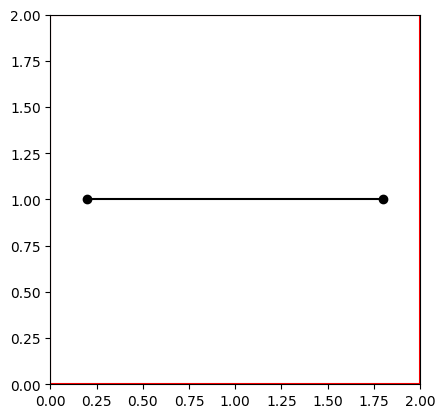

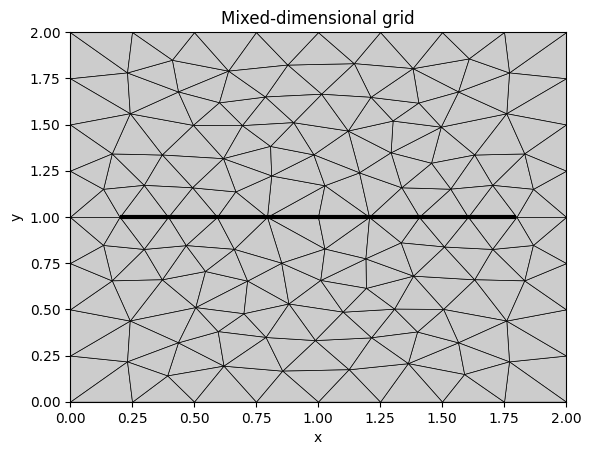

In [4]:
model_params = {
    "grid_type": "simplex",
}
model = GeometryModel(model_params)
model.prepare_simulation()
model.plot_fracture_geometry()
pp.plot_grid(
        model.mdg,
        figsize=(8,8),
        plot_2d=True, 
        fracturewidth_1d=3,
        linewidth=0.5,
        title="Mixed-dimensional grid",
        rgb=[0.8, 0.8, 0.8],
    )

Cartesian

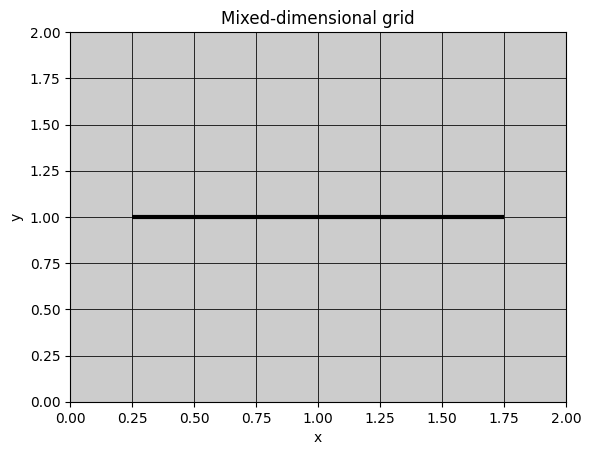

In [5]:
model_params = {
    "grid_type": "cartesian",
}
model = GeometryModel(model_params)
model.prepare_simulation()
pp.plot_grid(
    model.mdg,
    figsize=(8, 8),
    plot_2d=True,
    fracturewidth_1d=3,
    linewidth=0.5,
    title="Mixed-dimensional grid",
    rgb=[0.8, 0.8, 0.8],
)